# Customer Segmentation using K-Means

## Objective

The objective of this notebook is to segment customers based on their purchasing behavior using K-Means clustering.

The workflow includes:

- Loading the prepared dataset
- Determining the optimal number of clusters
- Training the K-Means model
- Evaluating clustering quality
- Assigning cluster labels
- Saving customer cluster assignments

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Load the prepared dataset

In [2]:
X = pd.read_csv(r"C:\Users\Lenovo\Customer-Intelligence-Platform\data\processed\customer_segmentation_dataset.csv")

In [3]:
X.head()

,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,customer_lifetime_days,recency_days,avg_basket_size,freight_ratio,has_review,delivery_completed
0,0.0,0.256882,0.0,-0.633686,0.282194,0.0,-0.652077,0.0,-0.461538,0.0,-0.622723,0.0,0.0
1,0.0,-1.280280,0.0,-1.228097,-1.289843,-1.0,-1.459432,0.0,-0.448718,0.0,0.771965,0.0,0.0
2,0.0,-0.210667,0.0,-0.036516,-0.195962,-2.0,1.295456,0.0,1.358974,0.0,0.106225,0.0,0.0
3,0.0,-0.845400,0.0,0.002851,-0.845096,-1.0,0.932886,0.0,0.435897,0.0,1.400427,0.0,0.0
4,0.0,0.565195,0.0,-0.068850,0.597503,0.0,0.347923,0.0,0.294872,0.0,-0.615017,0.0,0.0


### Find the optimal number of clusters

#### Method 1: Elbow Method

#### Method 2: Silhouette Score

### Comparing the 4 metrics: 
- Elbow Method (Inertia) ↓
- Silhouette Score ↑
- Calinski–Harabasz Index ↑
- Davies–Bouldin Index ↓

In [4]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

In [5]:
results = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X)

    results.append({
        "k": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(
            X,
            labels,
            sample_size=10000,
            random_state=42
        ),
        "Calinski_Harabasz": calinski_harabasz_score(
            X,
            labels
        ),
        "Davies_Bouldin": davies_bouldin_score(
            X,
            labels
        )
    })

results_df = pd.DataFrame(results)

results_df

,k,Inertia,Silhouette,Calinski_Harabasz,Davies_Bouldin
0,2,518255.568188,0.321496,26119.912079,1.467159
1,3,426652.915639,0.223877,26106.764899,1.526390
2,4,381112.856365,0.219945,23284.432017,1.462904
3,5,344980.386738,0.203560,21790.595252,1.388228
4,6,316746.250610,0.197251,20687.129155,1.323270
5,7,293251.466499,0.195474,19894.299168,1.363942
6,8,277168.726765,0.183407,18832.457980,1.464778
7,9,263013.819823,0.165194,18006.896611,1.487865
8,10,251613.693180,0.170399,17211.462653,1.461845


### Plotting inertia 

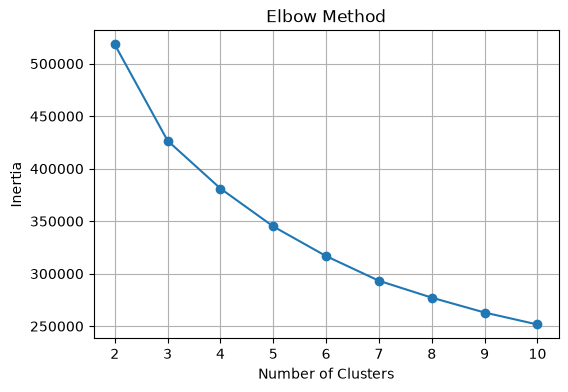

In [6]:
plt.figure(figsize=(6,4))

plt.plot(
    results_df["k"],
    results_df["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

### Plotting Silhoutte Score

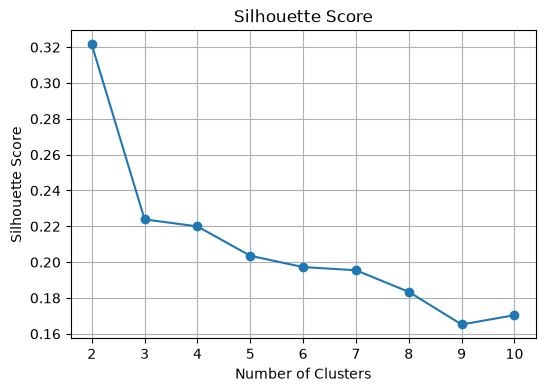

In [7]:
plt.figure(figsize=(6,4))

plt.plot(
    results_df["k"],
    results_df["Silhouette"],
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.grid(True)

plt.show()

### Plotting Calinski–Harabasz Index

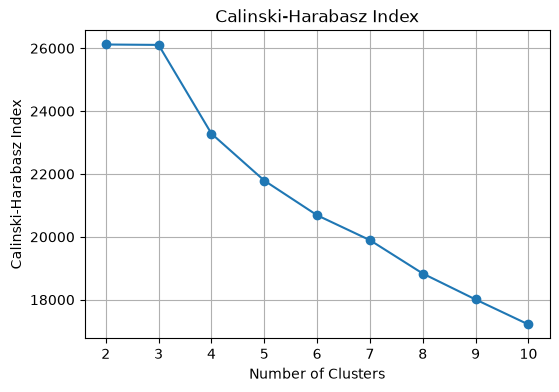

In [8]:
plt.figure(figsize=(6,4))

plt.plot(
    results_df["k"],
    results_df["Calinski_Harabasz"],
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Calinski-Harabasz Index")
plt.title("Calinski-Harabasz Index")

plt.grid(True)

plt.show()

### Plotting Davies–Bouldin Index

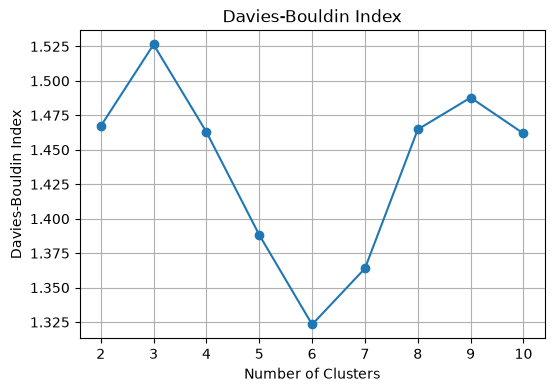

In [9]:
plt.figure(figsize=(6,4))

plt.plot(
    results_df["k"],
    results_df["Davies_Bouldin"],
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Index")

plt.grid(True)

plt.show()

### Train the 2 K-Means with 4 and 5 clusters 

In [10]:
kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)



In [11]:
clusters_4 = kmeans_4.fit_predict(X)

In [12]:
kmeans_5 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

clusters_5 = kmeans_5.fit_predict(X)

In [13]:
clusters4_df = X.copy()
clusters4_df["Cluster"] = clusters_4

In [14]:
clusters4_df["Cluster"].value_counts().sort_index()

Cluster
0    16650
1    35499
2    39388
3     3882
Name: count, dtype: int64

In [15]:
clusters5_df = X.copy()
clusters5_df["Cluster"] = clusters_5

In [16]:
clusters5_df["Cluster"].value_counts().sort_index()

Cluster
0     1886
1    34289
2    15605
3    13288
4    30351
Name: count, dtype: int64

### Load the original customer features

In [17]:
customer_features = pd.read_csv(
    "../../data/processed/customer_features.csv",
    parse_dates=["first_purchase", "last_purchase"]
)

customer_features["Cluster"] = clusters_4

### Profile the 4 customer segments using the original value

In [18]:
cluster_profile = customer_features.groupby("Cluster").agg({
    "total_orders": "mean",
    "total_spent": "mean",
    "total_products": "mean",
    "avg_order_value": "mean",
    "avg_review_score": "mean",
    "avg_delivery_days": "mean",
    "customer_lifetime_days": "mean",
    "recency_days": "mean",
    "freight_ratio": "mean"
}).round(2)

cluster_profile

,total_orders,total_spent,total_products,avg_order_value,avg_review_score,avg_delivery_days,customer_lifetime_days,recency_days,freight_ratio
Cluster,,,,,,,,,
0,1.01,165.71,1.18,164.39,1.63,19.93,0.02,251.46,0.21
1,1.01,255.73,1.12,253.82,4.69,12.56,0.01,245.21,0.14
2,1.00,63.16,1.04,62.96,4.64,9.65,0.02,240.98,0.27
3,1.62,391.94,3.24,294.26,3.99,12.09,65.64,219.17,0.23


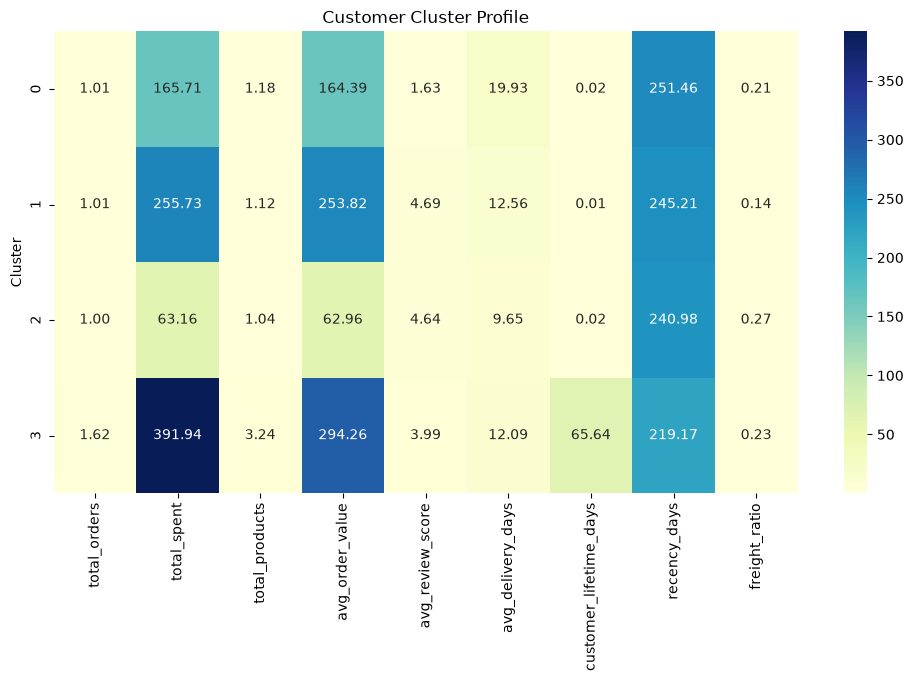

In [19]:
plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Customer Cluster Profile")
plt.show()

### Profile the 5 customer segments using the original value

In [20]:
customer_features["Cluster"] = clusters_5

In [21]:
cluster_sizes = (
    customer_features["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_sizes

Cluster
0     1886
1    34289
2    15605
3    13288
4    30351
Name: count, dtype: int64

In [22]:
(
    customer_features["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    *100
).round(2)

Cluster
0     1.98
1    35.94
2    16.35
3    13.93
4    31.81
Name: proportion, dtype: float64

In [23]:
cluster_profile = (
    customer_features
    .groupby("Cluster")
    .agg({
        "total_orders":"mean",
        "total_spent":"mean",
        "total_products":"mean",
        "total_freight_paid":"mean",
        "avg_order_value":"mean",
        "avg_review_score":"mean",
        "avg_delivery_days":"mean",
        "customer_lifetime_days":"mean",
        "recency_days":"mean",
        "avg_basket_size":"mean",
        "freight_ratio":"mean"
    })
    .round(2)
)

cluster_profile

,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,customer_lifetime_days,recency_days,avg_basket_size,freight_ratio
Cluster,,,,,,,,,,,
0,2.16,321.28,2.66,49.69,148.26,4.26,11.80,135.31,192.56,1.22,0.19
1,1.00,171.88,1.03,17.21,171.43,4.69,10.43,0.00,243.55,1.02,0.12
2,1.01,160.72,1.20,23.81,159.46,1.54,20.29,0.01,251.88,1.19,0.21
3,1.04,394.00,1.67,55.01,385.73,4.43,14.51,0.03,236.07,1.61,0.21
4,1.00,52.83,1.04,15.34,52.64,4.61,10.40,0.00,245.54,1.03,0.31


Although the Silhouette and Calinski–Harabasz indices favored fewer clusters, the five-cluster solution produced more meaningful and actionable customer segments. It successfully separated premium customers, loyal repeat buyers, dissatisfied customers, regular customers, and budget customers, providing greater business value while maintaining reasonable clustering quality. This balance between statistical evaluation and business interpretability led to the selection of k = 5 as the final model.

### Recommendation

**Choose: 5 clusters** — more actionable segmentation with manageable complexity.

---

### Why 5 clusters
- **Better separation** of high‑value and frequent buyers.  
- **Identifies problem group** (low review score / long delivery) for operational fixes.  
- **Higher marketing ROI** through targeted, differentiated campaigns.

---

### Quick comparison

| **Aspect** | **4 clusters** | **5 clusters** |
|---|---:|---:|
| **Granularity** | Low | **Higher** |
| **Problem detection** | Hidden | **Explicit** |
| **Operational effort** | Lower | Moderate |

---

### Recommended actions (brief)
- **Cluster 0 (frequent buyers):** VIP offers, subscriptions.  
- **Cluster 3 (high AOV):** Premium bundles, concierge outreach.  
- **Cluster 1 (mid spenders):** Upsell & repeat‑purchase campaigns.  
- **Cluster 2 (low reviews / slow delivery):** Investigate logistics, service recovery.  
- **Cluster 4 (low spend, large):** Low‑cost reactivation, free‑shipping thresholds.

---

### Rollout plan
1. **Pilot 4–8 weeks** with control groups.  
2. **Measure** revenue/user, repeat rate, review score, delivery SLA.  
3. **Scale or merge** segments based on measured ROI.

In [24]:
customer_features.head(5)

,customer_unique_id,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,first_purchase,last_purchase,customer_lifetime_days,recency_days,avg_basket_size,freight_ratio,R_score,F_score,M_score,RFM_score,Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,1.0,12.00,141.90,5.0,6.0,2018-05-10,2018-05-10,0,116,1.0,0.084567,4,1,4,414,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,1.0,8.29,27.19,4.0,3.0,2018-05-07,2018-05-07,0,119,1.0,0.304892,4,1,1,411,4
2,0000f46a3911fa3c0805444483337064,1,86.22,1.0,17.22,86.22,3.0,26.0,2017-03-10,2017-03-10,0,542,1.0,0.199722,1,1,2,112,2
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,1.0,17.63,43.62,4.0,20.0,2017-10-12,2017-10-12,0,326,1.0,0.404172,2,1,1,211,4
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,1.0,16.89,196.89,5.0,13.0,2017-11-14,2017-11-14,0,293,1.0,0.085784,2,1,4,214,1


### Save the final clustered dataset

In [25]:
customer_features.to_csv(
    "../../data/processed/customer_clusters.csv",
    index=False
)

### Save the trained model

In [30]:
import joblib

joblib.dump(
    kmeans_5,
    "../../model/customer_segmentation/kmeans_customer_segmentation.pkl"
)

['../../model/customer_segmentation/kmeans_customer_segmentation.pkl']